In [1]:
import time
import requests
from pathlib import Path
import pandas as pd

import mygene
from brainimagelibrary import retrieve, query

## Explore datasets

In [ ]:
datasets_path = Path("./data/cell_by_gene_files.tsv")

In [14]:
datasets = pd.read_csv(datasets_path, sep="\t")

In [29]:
datasets.groupby("bildid").size().sort_values(ascending=False)

bildid
ace-met-war    164
ace-let-lay    154
ace-let-law    122
ace-jig-eel    118
ace-ear-dud     53
              ... 
ace-low-ape      1
ace-low-arm      1
ace-low-art      1
ace-low-ash      1
ace-low-age      1
Length: 81, dtype: int64

## Explore cells by genes

In [30]:
df_path = Path('./data/gene_datasets - Gene × Dataset Matrix.csv')

In [31]:
df = pd.read_csv(df_path, index_col=0)

In [32]:
# change df to boolean
df = ~df.isna()
df.head()

,ace-ban-oat,ace-can-ill,ace-can-imp,ace-can-ink,ace-dry-dip,ace-dry-dog,ace-dry-dry,ace-dry-dub,ace-dud-vex,ace-dud-vow,...,ace-low-cap,ace-low-car,ace-low-cat,ace-low-cop,ace-low-cot,ace-low-cow,ace-low-cry,ace-low-cub,ace-low-zip,ace-met-war
Gene,,,,,,,,,,,,,,,,,,,,,
1500015O10Rik,True,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1700011I03Rik,True,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2900052N01Rik,False,False,False,False,False,False,False,False,False,False,...,True,True,True,True,True,True,True,True,True,False
4930509J09Rik,False,False,False,False,False,False,False,False,False,False,...,True,True,True,True,True,True,True,True,True,False
9030622O22Rik,True,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


## Get species taxids

In [34]:
# get species names from the metadata for each dataset

species_list = []
for i in range(len(df.columns)):
    metadata = retrieve.by_id(bildid=df.columns[i])
    species = metadata['retjson'][0]['Specimen'][0]['species']
    species_list.append(species)

species_list_unique = list(set(species_list))
species_list_unique 

['Human', 'human', 'Rhesus Macaque', 'mouse', 'Mouse']

In [43]:
def common_name_to_taxid(name):
    """Returns (taxid, scientific_name), or (None, None) if not found."""
    # Step 1: search by name to get taxid
    r = requests.get(
        "https://eutils.ncbi.nlm.nih.gov/entrez/eutils/esearch.fcgi",
        params={"db": "taxonomy", "term": name, "retmode": "json"},
    )
    ids = r.json().get("esearchresult", {}).get("idlist", [])
    if not ids:
        return None
    return int(ids[0])

def taxids_to_names(taxids):
    taxids = list(set(str(t) for t in taxids))  # dedupe
    r = requests.get(
        "https://eutils.ncbi.nlm.nih.gov/entrez/eutils/esummary.fcgi",
        params={"db": "taxonomy", "id": ",".join(taxids), "retmode": "json"},
    )
    result = r.json().get("result", {})
    return {int(tid): result.get(tid, {}).get("scientificname") for tid in taxids}

In [45]:
# from metadata entry to taxid
taxid_map = {}
for common_name in species_list_unique:
    taxid = common_name_to_taxid(common_name)

    taxid_map[common_name] = taxid

    time.sleep(0.33)
    
# from taxid to scientific name
name_map = taxids_to_names(list(taxid_map.values()))

for common_name, taxid in taxid_map.items():
    print(f"{common_name} -> {taxid} -> {name_map.get(taxid)}")

Human -> 9606 -> Homo sapiens
human -> 9606 -> Homo sapiens
Rhesus Macaque -> 9544 -> Macaca mulatta
mouse -> 10090 -> Mus musculus
Mouse -> 10090 -> Mus musculus


## Check gene names

In [ ]:
# find taxids for each column
def resolve(col):
    metadata = retrieve.by_id(bildid=col)
    species = metadata['retjson'][0]['Specimen'][0]['species']
    taxid = taxid_map.get(species)
    return taxid

col_taxid = {col: resolve(col) for col in df.columns}

In [ ]:
# get genes for each taxid
taxid_to_genes: dict[int, set[str]] = {}
for col, taxid in col_taxid.items():
    present = df.index[df[col]]
    taxid_to_genes.setdefault(taxid, set()).update(present)

In [61]:
len(taxid_to_genes)

3

In [ ]:
from enum import Enum
from typing import Iterable

mg = mygene.MyGeneInfo()

class MatchStatus(str, Enum):
    SYMBOL = "symbol"   # exact match against the current official symbol
    ALIAS = "alias"     # match against alias / ensembl / entrez (not current symbol)
    NONE = "none"       # no match at all


def classify_for_species(
    genes: Iterable[str],
    taxid: int,
    mg: mygene.MyGeneInfo,
) -> dict[str, MatchStatus]:
    """Two-pass query: strict symbol first, fuzzy scopes only on the misses."""
    genes = sorted(set(genes))
    if not genes:
        return {}

    # Pass 1 — exact symbol only
    r1 = mg.querymany(
        genes, scopes="symbol", fields="symbol",
        species=taxid, returnall=True,
    )
    symbol_hits = {h["query"] for h in r1["out"] if not h.get("notfound")}
    misses = list(r1["missing"])

    # Pass 2 — alias / xref scopes, only on what didn't resolve as a symbol
    alias_hits: set[str] = set()
    if misses:
        r2 = mg.querymany(
            misses, scopes="alias,ensembl.gene,entrezgene,name", fields="symbol",
            species=taxid, returnall=True,
        )
        alias_hits = {h["query"] for h in r2["out"] if not h.get("notfound")}

    def status(g: str) -> MatchStatus:
        if g in symbol_hits: return MatchStatus.SYMBOL
        if g in alias_hits:  return MatchStatus.ALIAS
        return MatchStatus.NONE

    return {g: status(g) for g in genes}


In [60]:
status_by_taxid = {
    taxid: pd.Series(
        {g: s.value for g, s in classify_for_species(genes, taxid, mg).items()}
    )
    for taxid, genes in taxid_to_genes.items()
}

1 input query terms found dup hits:	[('B230209E15Rik', 2)]
48 input query terms found no hit:	['1500015O10Rik', '1700011I03Rik', 'Cars', 'Fyb', 'Hist1h1d', 'Lhfp', 'Prrxl1', 'Sept4', 'blank-0', 
2 input query terms found dup hits:	[('Lhfp', 2), ('volume', 10)]
38 input query terms found no hit:	['blank-0', 'blank-1', 'blank-10', 'blank-11', 'blank-12', 'blank-13', 'blank-14', 'blank-15', 'blan
10 input query terms found dup hits:	[('CASC6', 2), ('DLX6-AS1', 2), ('IGHA1', 2), ('LINC01965', 2), ('LINC02822', 2), ('NR2F2-AS1', 2), 
5 input query terms found no hit:	['FAM155A', 'FAM160A1', 'FAM189A2', 'NDUFA4L2', 'TCTEX1D1']
4 input query terms found dup hits:	[('ADCYAP1', 2), ('CLDN5', 2), ('DPF3', 2), ('TSHZ2', 2)]
1 input query terms found no hit:	['ZNF429']


In [63]:
# Broadcast back: for each column, look up its species' status table,
# then mask out genes that aren't actually present in that dataset.
out = pd.DataFrame(index=df.index, columns=df.columns, dtype=object)
for col, taxid in col_taxid.items():
    s = status_by_taxid[taxid].reindex(df.index)
    out[col] = s.where(df[col].fillna(False).astype(bool))

In [64]:
out

,ace-ban-oat,ace-can-ill,ace-can-imp,ace-can-ink,ace-dry-dip,ace-dry-dog,ace-dry-dry,ace-dry-dub,ace-dud-vex,ace-dud-vow,...,ace-low-cap,ace-low-car,ace-low-cat,ace-low-cop,ace-low-cot,ace-low-cow,ace-low-cry,ace-low-cub,ace-low-zip,ace-met-war
Gene,,,,,,,,,,,,,,,,,,,,,
1500015O10Rik,alias,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1700011I03Rik,alias,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2900052N01Rik,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,symbol,symbol,symbol,symbol,symbol,symbol,symbol,symbol,symbol,NaN
4930509J09Rik,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,symbol,symbol,symbol,symbol,symbol,symbol,symbol,symbol,symbol,NaN
9030622O22Rik,symbol,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
global_y,none,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mRNA_counts,none,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
median_total_density,none,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [76]:
out['ace-ban-oat'].value_counts()

ace-ban-oat
symbol    285
none       38
alias       5
Name: count, dtype: int64

In [77]:
df['ace-ban-oat'].value_counts()

ace-ban-oat
False    2023
True      328
Name: count, dtype: int64

In [69]:
summary = (
    out.apply(lambda c: c.value_counts())
             .reindex(["symbol", "alias", "none"])
             .fillna(0).astype(int)
             .T   # datasets as rows, statuses as columns
)

<Axes: >

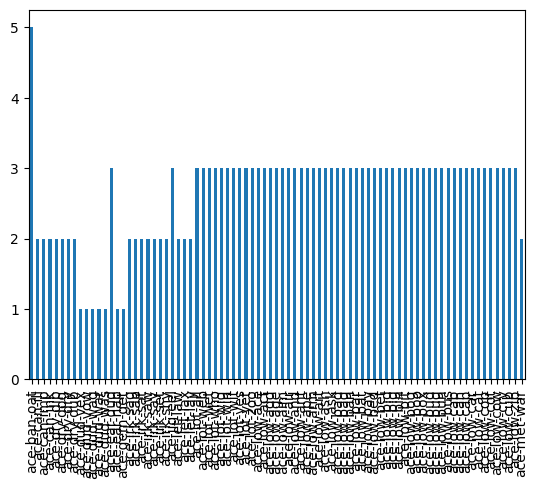

In [78]:
# only a single dataset contains no matches
summary["alias"].plot(kind="bar")

<Axes: >

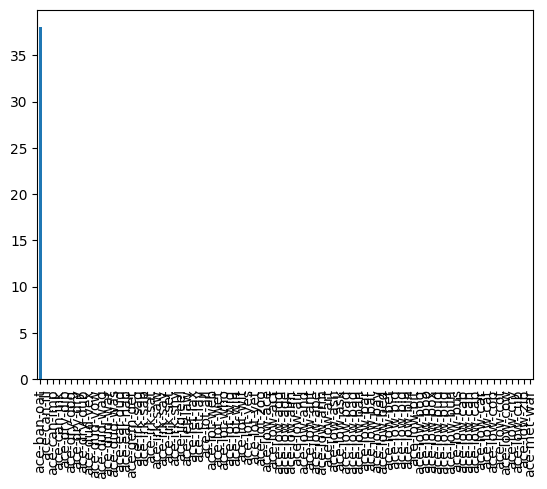

In [ ]:
# only a single dataset contains no matches
summary["none"].plot(kind="bar")

In [80]:
out.loc[out['ace-ban-oat']=='none','ace-ban-oat']

Gene
blank-0                 none
blank-1                 none
blank-10                none
blank-11                none
blank-12                none
blank-13                none
blank-14                none
blank-15                none
blank-16                none
blank-17                none
blank-18                none
blank-19                none
blank-2                 none
blank-20                none
blank-21                none
blank-22                none
blank-23                none
blank-24                none
blank-25                none
blank-26                none
blank-3                 none
blank-4                 none
blank-5                 none
blank-6                 none
blank-7                 none
blank-8                 none
blank-9                 none
blank_IEG-0             none
blank_IEG-1             none
blank_IEG-2             none
blank_IEG-3             none
fov_x                   none
fov_y                   none
global_x                none
global_y 